# The SpekPy notebook
An interactive Python session using SpekPy. Click on **Run** to run a code block.

An example: calculating a first half-value-layer and plotting a spectrum

HVL 5.267239905222598 mm
spectrum name
C:\Users\SNUH\Downloads\spekpy-spekpy_release-8c3df59ec333\test.txt


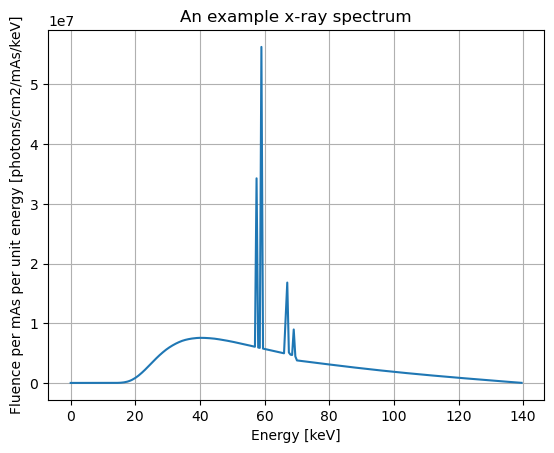

In [ ]:
import spekpy as sp  # Import SpekPy library
import matplotlib.pyplot as plt  # Import Matplotlib 
import pandas as pd  # Import Pandas 
import numpy as np  # Import NumPy

# 100 kVp, 14deg thickness
s = sp.Spek(kvp=140, th=14)

# 2.7 mm Inherent Filter
s.filter('Al', 2.7)
# Collimator polycarbon window
s.filter('Al', 0.3)
# Beam hardening foil filter
s.filter('Ti', 0.89)
# Full-Fan bowtie filter
s.filter('Al', 1.53)


# First HVL value
hvl = s.get_hvl1()
print('HVL', hvl, 'mm')  # HVL value output

# Spectrum energy(k) and  fluence(f) value
k, f = s.get_spectrum(edges=True)
s.export_spectrum('test.txt', comment='A demo spectrum export')
# k between 1 and 140, increments of 0.5
new_k = np.arange(0, 140, 0.5)
new_f = np.interp(new_k, k, f)  # interpolate f with new_k

# spectrum
plt.plot(new_k, new_f)
#plt.plot(k, f)
plt.xlabel('Energy [keV]')
plt.ylabel('Fluence per mAs per unit energy [photons/cm2/mAs/keV]')
plt.title('An example x-ray spectrum')
plt.grid(True)
plt.show()

# new k and interpolated f values into DataFrame
df = pd.DataFrame({'Energy [keV]': new_k, 'Fluence [photons/cm2/mAs/keV]': new_f})

# Save DataFrame to a CSV file
df.to_csv('spectrum_data.csv', index=False)

Now it's your turn. Enter your code below. Or open a new notebook.

In [ ]:
# For compatibility with Python2
from __future__ import print_function, division, absolute_import
#

import spekpy as sp
import numpy as np
print("\n** Script to generate the NIST M150 spectrum filtered to match the NIST reference HVL **\n")

print("Reference hvl:", 10.3, "mmAl")

# Generate unfiltered spectrum
s=sp.Spek(kvp=150,th=20)
# Apply base filtering
s.filter('Be',3.0).filter('Al',5.25).filter('Air',966.8)
# Find thickness of copper to add to give specified HVL
tCu=s.get_matl(matl='Cu',hvl_matl='Al',hvl=10.3)

print("Estimated additional filtration:", tCu, "mmCu")

# Apply that thickness Cu filtration
s.filter('Cu',tCu)
# Get the first HVL in mm Al
hvl1=s.get_hvl1(matl='Al')
# Get the thickness of Al that halves air kerma
hvl1check=s.get_matl(matl='Al',frac=0.5)

assert np.isclose(hvl1,hvl1check), \
    "Inconsistancy in get_matll(): frac mode result disagrees with hvl mode"

print("Obtained hvl:", hvl1, "mmAl\n")



** Script to generate the NIST M150 spectrum filtered to match the NIST reference HVL **

Reference hvl: 10.3 mmAl
Estimated additional filtration: 0.30575872248621205 mmCu
Obtained hvl: 10.300000050196255 mmAl



In [ ]:
# For compatibility with Python2
from __future__ import print_function, division, absolute_import
#

import spekpy as sp
print("\n**Script to generate a filtered spectrum normalized to a reference air kerma **\n")

# Generate unfiltered spectrum
s=sp.Spek(kvp=120,th=12)
# Filter the spectrum
s.filter('Be',1.0).filter('Al',4.0).filter('Air',1000)
print('* Unnormalized air kerma values *')
print('Air Kerma at (x,y,z)=(0 cm, 0 cm, 100 cm):',s.get_kerma(),'uGy')
print('Air Kerma at (x,y,z)=(10 cm, 0 cm, 100 cm):',s.get_kerma(x=10),'uGy')
print()
# See air kerma at reference point and at 10 cm displaced in anode-cathode direction
print('* Air kerma values after normalization to reference point *')
s.set(ref_kerma=100)
print('Air Kerma at (x,y,z)=(0 cm, 0 cm, 100 cm):',s.get_kerma(),'uGy')
print('Air Kerma at (x,y,z)=(10 cm, 0 cm, 100 cm):',s.get_kerma(x=10),'uGy')
print()
print('* Air kerma values after setting new reference point (defaults to unnormalized) *')
s.set(x=10)
print('Air Kerma at (x,y,z)=(0 cm, 0 cm, 100 cm):',s.get_kerma(x=0),'uGy')
print('Air Kerma at (x,y,z)=(10 cm, 0 cm, 100 cm):',s.get_kerma(),'uGy')
print()
print('* Air kerma values after normalization to new reference point *')
s.set(ref_kerma=100)
print('Air Kerma at (x,y,z)=(0 cm, 0 cm, 100 cm):',s.get_kerma(x=0),'uGy')
print('Air Kerma at (x,y,z)=(10 cm, 0 cm, 100 cm):',s.get_kerma(),'uGy')
print()



**Script to generate a filtered spectrum normalized to a reference air kerma **

* Unnormalized air kerma values *
Air Kerma at (x,y,z)=(0 cm, 0 cm, 100 cm): 110.95284058892499 uGy
Air Kerma at (x,y,z)=(10 cm, 0 cm, 100 cm): 118.56939732388774 uGy

* Air kerma values after normalization to reference point *
Air Kerma at (x,y,z)=(0 cm, 0 cm, 100 cm): 99.99999999999999 uGy
Air Kerma at (x,y,z)=(10 cm, 0 cm, 100 cm): 106.86467934893322 uGy

* Air kerma values after setting new reference point (defaults to unnormalized) *
Air Kerma at (x,y,z)=(0 cm, 0 cm, 100 cm): 110.95284058892499 uGy
Air Kerma at (x,y,z)=(10 cm, 0 cm, 100 cm): 118.56939732388774 uGy

* Air kerma values after normalization to new reference point *
Air Kerma at (x,y,z)=(0 cm, 0 cm, 100 cm): 93.57628788973504 uGy
Air Kerma at (x,y,z)=(10 cm, 0 cm, 100 cm): 99.99999999999997 uGy



In [ ]:
help(s.export_spectrum)

Help on method export_spectrum in module spekpy.SpekPy:

export_spectrum(file_name=None, comment=None, delim=';') method of spekpy.SpekPy.Spek instance
    An internal method that can be used to export a spectrum to disk
    
    :param str file_name: The file name of the exported spectrum
    :param str comment: A comment that will be included in the exported 
        spectrum
    :return:

